# Taller 7: Fundamentos de Machine Learning y Redes Neuronales

### Sebastián Palma

### David Tobón Molina

In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import cv2
import json
from tensorflow import keras
from kaggle.api.kaggle_api_extended import KaggleApi
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

## 1. Preprocesamiento de Datos

### 1.1 Descarga y Preparación del Dataset

In [4]:
with open('./kaggle.json') as f:
    kaggle_credentials = json.load(f)

os.environ['KAGGLE_USERNAME'] = kaggle_credentials['username']
os.environ['KAGGLE_KEY'] = kaggle_credentials['key']

api = KaggleApi()
api.authenticate()
api.dataset_download_files('carlosrunner/pizza-not-pizza', path='data', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/carlosrunner/pizza-not-pizza


### 1.2 Exploración de Imágenes

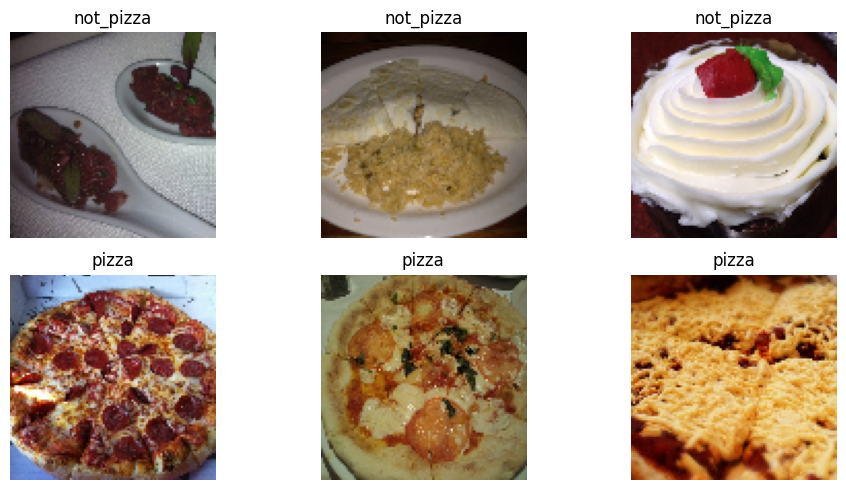

In [6]:
data_dir = 'data/pizza_not_pizza'
categories = os.listdir(data_dir)

plt.figure(figsize=(10, 5))

for i, category in enumerate(categories):
    folder = os.path.join(data_dir, category)
    images = os.listdir(folder)[:3]  
    
    for j, image_file in enumerate(images):
        img_path = os.path.join(folder, image_file)
        img = keras.preprocessing.image.load_img(img_path, target_size=(100, 100))
        img_array = keras.preprocessing.image.img_to_array(img) / 255.0
        plt.subplot(len(categories), 3, i*3 + j + 1)
        plt.imshow(img_array)
        plt.title(category)
        plt.axis('off')

plt.tight_layout()
plt.show()

### 1.3 Preparación de Datos y División en Entrenamiento, Validación y Test

In [7]:
filepaths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(data_dir) for f in filenames if os.path.splitext(f)[1].lower() in ['.png','.jpg','.jpeg']]
labels = [os.path.split(os.path.split(path)[0])[1] for path in filepaths]
data_df = pd.DataFrame({'filepath': filepaths, 'label': labels})

train_df, test_val_df = train_test_split(data_df, test_size=0.3, random_state=42)
test_df, val_df = train_test_split(test_val_df, test_size=2/3, random_state=42)

print("Total de imágenes:", len(data_df))
print("Entrenamiento:", len(train_df))
print("Validación:", len(val_df))
print("Test:", len(test_df))

Total de imágenes: 1966
Entrenamiento: 1376
Validación: 394
Test: 196


### 1.4 Procesamiento y Generadores de Imágenes

In [8]:
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)

test_val_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

train_gen = train_datagen.flow_from_dataframe(
    train_df, 
    x_col='filepath', 
    y_col='label',
    target_size=(100, 100), 
    batch_size=32
)
val_gen = test_val_datagen.flow_from_dataframe(
    val_df, 
    x_col='filepath',
    y_col='label',
    target_size=(100, 100), 
    batch_size=32, 
    shuffle=False
)
test_gen = test_val_datagen.flow_from_dataframe(
    test_df, 
    x_col='filepath', 
    y_col='label',
    target_size=(100, 100), 
    batch_size=32, 
    shuffle=False
)

Found 1376 validated image filenames belonging to 2 classes.
Found 394 validated image filenames belonging to 2 classes.
Found 196 validated image filenames belonging to 2 classes.


Las técnicas de preprocesamiento implementadas en este modelo fueron seleccionadas considerando las características del dataset Pizza vs Not Pizza:

* Normalización: Se aplicó normalización mediante la transformación de los valores de los píxeles desde el rango $ [0,255] $ al rango $ [0,1] $. Esto ya que permite que los valores de entrada se mantengan en una escala homogénea, evitando que valores grandes dominen el proceso de aprendizaje. Lo que logra una convergencia más rápida y estable durante el entrenamiento, lo cual se refleja en un comportamiento más suave de la función de pérdida.

* Data Augmentation: Se aplicaron técnicas de aumentación de datos como rotación y volteo horizontal con el fin de introducir mayor variabilidad en las imágenes de entrenamiento. Estas transformaciones permiten simular diferentes condiciones en las que podría aparecer una pizza, enriqueciendo el conjunto de datos sin necesidad de recolectar nuevas imágenes.

* Redimensionamiento de imágenes: Las imágenes fueron redimensionadas a un tamaño uniforme de 100×100 píxeles para garantizar compatibilidad con el modelo. El tamaño representa un balance adecuado entre la preservación de características relevantes y la eficiencia computacional. Lo que permite reducir disminuir el número de parámetros y el tiempo de entrenamiento sin perder información crítica para la clasificación.

## 2. Construcción de un Modelo de Red Neuronal Perceptrón Multicapa

### 2.1 Construcción y Compilación del Modelo

In [18]:
model = Sequential([
    Flatten(input_shape=(100, 100, 3)),    
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dense(len(categories), activation='softmax')
])

model.summary()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

c:\Users\sebas\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 30000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │    15,360,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,492,354 (59.10 MB)

 Trainable params: 15,492,354 (59.10 MB)

 Non-trainable params: 0 (0.00 B)

La arquitectura del modelo fue diseñada para el problema de clasificación de imágenes Pizza vs Not Pizza, utilizando un perceptrón multicapa y buscando un equilibrio entre simplicidad y capacidad de aprendizaje:

1. Capa Flatten: Se encarga de transformar la imagen de entrada en un vector unidimensional. Esto permite simplificar el modelo y ayuda a capturar patrones generales en problemas de clasificación binaria como este.

2. Capa Dense: Esta capa densa proporciona al modelo una alta capacidad para aprender patrones relevantes presentes en las imágenes, con 512 neuronas. Además, se utiliza la función de activación ReLU para modelar relaciones no lineales y facilitar el entrenamiento, evitando problemas como el desvanecimiento del gradiente. El número elevado de neuronas busca capturar características iniciales de alto nivel como texturas, colores y formas generales.

3. Capa Dropout: Se incluye una capa de regularización tipo Dropout con una tasa de 0.2, lo que implica que durante el entrenamiento el 20% de las neuronas se desactiva aleatoriamente. Esto promueve que el modelo aprenda representaciones más robustas y reduce el riesgo de sobreajuste.

4. Segunda capa Dense: La segunda capa densa reduce el número de neuronas a 256, permitiendo una compresión progresiva de la información aprendida. Esta reducción actúa como un mecanismo de refinamiento, donde el modelo conserva únicamente las características más relevantes.

5. Capa de salida Dense: La capa final contiene tantas neuronas como clases en el problema y utiliza la función de activación softmax. Esta función transforma la salida del modelo en probabilidades asociadas a cada clase, facilitando la interpretación de los resultados.

## 3. Definición de Funciones de Callbacks para Monitorear el Entrenamiento

### 3.1 Entrenamiento del Modelo

In [19]:
model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss', mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')
callbacks = [model_checkpoint, early_stopping, reduce_lr]

# Entrenamiento
with tf.device('/device:GPU:0'):
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=50,
        callbacks=callbacks
    )

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.5221 - loss: 7.6002

43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - accuracy: 0.5334 - loss: 4.2043 - val_accuracy: 0.6244 - val_loss: 0.7037 - learning_rate: 0.0010
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.5545 - loss: 1.1788 - val_accuracy: 0.5533 - val_loss: 0.9178 - learning_rate: 0.0010
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - accuracy: 0.6163 - loss: 0.7419 - val_accuracy: 0.5584 - val_loss: 0.8161 - learning_rate: 0.0010
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.6156 - loss: 0.7111

43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - accuracy: 0.6163 - loss: 0.7122 - val_accuracy: 0.6244 - val_loss: 0.6750 - learning_rate: 0.0010
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.6315 - loss: 0.6840 - val_accuracy: 0.6015 - val_loss: 0.6772 - learning_rate: 0.0010
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - accuracy: 0.6294 - loss: 0.6623 - val_accuracy: 0.6244 - val_loss: 0.7017 - learning_rate: 0.0010
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.6510 - loss: 0.6608

43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - accuracy: 0.6337 - loss: 0.6565 - val_accuracy: 0.6091 - val_loss: 0.6565 - learning_rate: 0.0010
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - accuracy: 0.6490 - loss: 0.6187 - val_accuracy: 0.6193 - val_loss: 0.6729 - learning_rate: 0.0010
Epoch 9/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - accuracy: 0.6781 - loss: 0.6212 - val_accuracy: 0.6345 - val_loss: 0.6763 - learning_rate: 0.0010
Epoch 10/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.6646 - loss: 0.6207

43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step - accuracy: 0.6759 - loss: 0.6037 - val_accuracy: 0.6421 - val_loss: 0.6327 - learning_rate: 0.0010
Epoch 11/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - accuracy: 0.6570 - loss: 0.6129 - val_accuracy: 0.6244 - val_loss: 0.6346 - learning_rate: 0.0010
Epoch 12/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - accuracy: 0.6170 - loss: 0.6407 - val_accuracy: 0.6269 - val_loss: 0.6436 - learning_rate: 0.0010
Epoch 13/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.6701 - loss: 0.6085 - val_accuracy: 0.6269 - val_loss: 0.6482 - learning_rate: 0.0010
Epoch 14/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.6599 - loss: 0.6211 - val_accuracy: 0.6269 - val_loss: 0.6435 - learning_rate: 0.0010
Epoch 15/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.6666 - loss: 0.6281
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accuracy: 0.6650 - loss: 0.6248 - val_a

...

43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - accuracy: 0.6868 - loss: 0.5888 - val_accuracy: 0.6624 - val_loss: 0.6198 - learning_rate: 1.0000e-04
Epoch 20/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - accuracy: 0.6919 - loss: 0.5895 - val_accuracy: 0.6472 - val_loss: 0.6225 - learning_rate: 1.0000e-04
Epoch 21/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 145ms/step - accuracy: 0.6839 - loss: 0.5875 - val_accuracy: 0.6574 - val_loss: 0.6290 - learning_rate: 1.0000e-04
Epoch 22/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7105 - loss: 0.5544

43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step - accuracy: 0.6911 - loss: 0.5789 - val_accuracy: 0.6497 - val_loss: 0.6186 - learning_rate: 1.0000e-04
Epoch 23/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step - accuracy: 0.6890 - loss: 0.5847 - val_accuracy: 0.6497 - val_loss: 0.6253 - learning_rate: 1.0000e-04
Epoch 24/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.7209 - loss: 0.5639

43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 156ms/step - accuracy: 0.7071 - loss: 0.5739 - val_accuracy: 0.6574 - val_loss: 0.6179 - learning_rate: 1.0000e-04
Epoch 25/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.7196 - loss: 0.5618

43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 144ms/step - accuracy: 0.7057 - loss: 0.5733 - val_accuracy: 0.6624 - val_loss: 0.6163 - learning_rate: 1.0000e-04
Epoch 26/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.6959 - loss: 0.5800

43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - accuracy: 0.6962 - loss: 0.5705 - val_accuracy: 0.6497 - val_loss: 0.6119 - learning_rate: 1.0000e-04
Epoch 27/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.7078 - loss: 0.5728 - val_accuracy: 0.6421 - val_loss: 0.6203 - learning_rate: 1.0000e-04
Epoch 28/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - accuracy: 0.7042 - loss: 0.5683 - val_accuracy: 0.6421 - val_loss: 0.6219 - learning_rate: 1.0000e-04
Epoch 29/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - accuracy: 0.7035 - loss: 0.5801 - val_accuracy: 0.6396 - val_loss: 0.6196 - learning_rate: 1.0000e-04
Epoch 30/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.7035 - loss: 0.5798 - val_accuracy: 0.6548 - val_loss: 0.6251 - learning_rate: 1.0000e-04
Epoch 31/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.7378 - loss: 0.5532
Epoch 31: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.7253 - 

Las funciones de callbacks implementadas en este modelo fueron seleccionadas con el objetivo de monitorear y optimizar el proceso de entrenamiento:

* ModelCheckpoint: Permite guardar automáticamente el modelo que presenta el mejor desempeño durante el entrenamiento, utilizando como criterio la minimización de la pérdida en el conjunto de validación (val_loss). Esto garantiza que, independientemente del comportamiento del modelo en épocas posteriores, se conserve la mejor versión obtenida. 

* EarlyStopping:Se encarga de detener el entrenamiento cuando la pérdida de validación deja de mejorar durante un número determinado de épocas. Esto permite evitar el sobreentrenamiento del modelo, reduciendo el riesgo de sobreajuste y optimizando el tiempo de cómputo. Además, mediante el parámetro restore_best_weights=True, se asegura que el modelo final corresponda al mejor desempeño observado durante el entrenamiento.

* ReduceLROnPlateau: Ajusta dinámicamente la tasa de aprendizaje cuando el modelo deja de mostrar mejoras en la pérdida de validación. En este caso, si no se observa mejora durante 5 épocas, la tasa de aprendizaje se reduce en un factor de 0.1. Esta estrategia permite realizar ajustes más finos en etapas avanzadas del entrenamiento, facilitando la convergencia hacia mínimos más óptimos y evitando que el modelo se estanque.

## 4. Entrenamiento y Exploración de Resultados

### 4.1 Evaluación del Modelo